# Tutorial 04: Latrophilin-1 Mutation Analysis

## Introduction

This notebook compares two molecular dynamics simulations of **Latrophilin-1** (**ADGRL1 / LPHN1**): a **wild-type (WT)** system and the **F840K** mutant. The goal is intentionally simple: identify which residue-residue contacts differ most strongly between both conditions and visualize these changes in a compact, interpretable way.

## Simulation Background

Latrophilin-1 is an adhesion GPCR. In this receptor class, the **GAIN domain** modulates the exposure of the tethered agonist. That makes local structural flexibility and interaction patterns especially interesting when comparing variants. Here we use precomputed trajectories for ADGRL1 and focus on contact-level differences between WT and mutant.

## Source of the Simulation

The trajectories used in this tutorial are fetched from the **Proteinformatics server** and stored locally in the expected tutorial folder structure under `../data/L1/`. This keeps the notebook reproducible while still allowing `mdxplain` to load the files from a normal on-disk dataset layout.

The systems correspond to the Latrophilin-1 simulations discussed in the following study:

- Beliu G, Altrichter S, Guixa-Gonzalez R, et al. *Tethered agonist exposure in intact adhesion/class B2 GPCRs through intrinsic structural flexibility of the GAIN domain*. **Molecular Cell** 81(5), 905-921.e5 (2021). DOI: `10.1016/j.molcel.2020.12.042`
- Computational dataset for the manuscript on **Zenodo**. DOI: `10.5281/zenodo.6510766`


## Download the Tutorial Files

Before loading the trajectories, we create the expected directory structure under `../data/L1/` and download the required files if they are missing. This keeps the notebook self-contained and ensures that the later `load_trajectories("../data/L1")` call sees a standard nested dataset layout.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

base_url = "https://proteinformatics.uni-leipzig.de/mdxplain/tutorial_simulations/L1"
data_root = Path("../data/L1")

files_to_download = {
    "L1Rep1/L1rep1.gro": data_root / "L1Rep1" / "L1rep1.gro",
    "L1Rep1/L1rep1.xtc": data_root / "L1Rep1" / "L1rep1.xtc",
    "L1_3_AL/L1+3_AL.pdb": data_root / "L1_3_AL" / "L1+3_AL.pdb",
    "L1_3_AL/L1+3_rep1.xtc": data_root / "L1_3_AL" / "L1+3_rep1.xtc",
}

for remote_path, local_path in files_to_download.items():
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists():
        print(f"Already present: {local_path}")
        continue

    url = f"{base_url}/{remote_path.lstrip('/')}"
    print(f"Downloading {url} -> {local_path}")
    urlretrieve(url, local_path)

print("Latrophilin tutorial data ready in ../data/L1/")


Already present: ..\data\L1\L1Rep1\L1rep1.gro
Already present: ..\data\L1\L1Rep1\L1rep1.xtc
Already present: ..\data\L1\L1_3_AL\L1+3_AL.pdb
Already present: ..\data\L1\L1_3_AL\L1+3_rep1.xtc
Latrophilin tutorial data ready in ../data/L1/



## Start of the mdxplain Pipeline - Import

We only import the `PipelineManager`, because the full workflow is coordinated from this single entry point. This keeps the notebook focused on the analysis logic rather than on low-level object management.

In [2]:
from mdxplain import PipelineManager

## Initialize the Pipeline

We create one pipeline object that will store trajectories, metadata, features, comparisons, plots, and export results. Memory mapping is enabled so larger arrays can stay on disk, which is useful for MD workflows and keeps RAM usage predictable.


In [3]:
pipeline = PipelineManager(use_memmap=True, chunk_size=1000, show_progress=False)

## Load the Simulation Data

After the download step, the Latrophilin-1 files are available in the expected tutorial directory structure under `../data/L1/`. We now load the WT and F840K systems into the pipeline so all later feature extraction and mutation-specific comparisons operate on the same prepared input.


In [4]:
pipeline.trajectory.load_trajectories("../data/L1")

📦 Creating Zarr cache: C:\Users\maxim\Documents\projects\mdxplain\tutorials\cache\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\L1Rep1_L1rep1_L1rep1_2be78a19.dask.zarr
  🔍 Analyzing trajectory dimensions...
  📐 Trajectory: 1008 frames × 5664 atoms
  💾 Writing trajectory data...
  ✅ Cache created: C:\Users\maxim\Documents\projects\mdxplain\tutorials\cache\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\L1Rep1_L1rep1_L1rep1_2be78a19.dask.zarr
  📊 Size: 49.9 MB
📦 Creating Zarr cache: C:\Users\maxim\Documents\projects\mdxplain\tutorials\cache\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\L1_3_AL_L1+3_AL_L1+3_rep1_e9396101.dask.zarr
  🔍 Analyzing trajectory dimensions...
  📐 Trajectory: 5001 frames × 5666 atoms
  💾 Writing trajectory data...
  ✅ Cache created: C:\Users\maxim\Documents\projects\mdxplain\tutorials\cache\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\L1_3_AL_L1+3_AL_L1+3_rep1_e9396101.dask.zarr
  📊 Size: 245.2 MB

Loaded 2 systems with 2 total 

## Assign Readable Names

The raw trajectory indices are renamed to biologically meaningful labels. This matters because all later plots and comparisons should clearly communicate which system is **WT** and which is **F840K**.


In [5]:
pipeline.trajectory.rename_trajectories({
    0: "L1 WT",
    1: "L1 F840K"
})

## Add Condition Tags

We attach simple tags to the trajectories so the systems can be selected by condition later on. This is useful for mutation analyses, because comparisons are usually defined in terms of groups such as `WT` and `MT` rather than by numeric trajectory IDs.


In [6]:
pipeline.trajectory.add_tags(trajectory_selector=0, tags=["WT"])
pipeline.trajectory.add_tags(trajectory_selector=1, tags=["MT"])

## Add Residue Labels and GPCR Numbering

This step adds residue metadata and configures the fragment as a GPCR system using **GPCRdb-style numbering**. The extra annotation makes downstream contact importance results easier to interpret, because the relevant residues can later be mapped back to meaningful receptor positions.


In [7]:
pipeline.trajectory.add_labels(
    traj_selection="all",
    consensus=True,
    aa_short=True,
    fragment_definition={
        "L1": (0, 367)
    },
    fragment_type={
        "L1": "gpcr"    # GPCRdb numbering
    },
    fragment_molecule_name={
        "L1": "agrl1_human"
    },
)

Please cite the following reference to the GPCRdb:
 * Kooistra et al, (2021) GPCRdb in 2021: Integrating GPCR sequence, structure and function
   Nucleic Acids Research 49, D335--D343
   https://doi.org/10.1093/nar/gkaa1080
Please cite the following reference to the GAIN nomenclature:
 * Florian Seufert et al, (2025) Generic residue numbering of the GAIN domain of adhesion GPCRs
   Nature Communications 2024 16:1 16, 1-11
   https://doi.org/10.1038/s41467-024-55466-6
For more information, call mdciao.nomenclature.references()
wrote C:\Users\maxim\Documents\projects\mdxplain\tutorials\cache\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\agrl1_human.xlsx for future use
C:\Users\maxim\Documents\projects\mdxplain\tutorials\cache\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\agrl1_human.xlsx found locally.


## Compute Structural Features

We calculate residue-residue **distances** and binary **contacts**. For this notebook, contacts are the key representation, because mutation effects often appear as interaction gains or losses.


In [8]:
pipeline.feature.add.distances()
pipeline.feature.add.contacts(cutoff=4.5)

Generated 66431 residue pairs for 366 residues
Generated 66431 residue pairs for 366 residues


## Focus the Analysis on Contacts

The feature selector keeps only contact features for the downstream comparison. This reduces complexity and aligns the analysis with the central biological question: **which interactions are rewired by the mutation?**


In [9]:
pipeline.feature_selector.create("contacts_only")
pipeline.feature_selector.add.contacts("contacts_only", "all", common_denominator=False)
pipeline.feature_selector.select("contacts_only")

Created feature selector: 'contacts_only'
Added to selector 'contacts_only': contacts -> 'all' (use_reduced=False, common_denominator=False, traj_selection=all, require_all_partners=False)
Applied feature selector 'contacts_only' with reference trajectory 0 successfully


## Define the WT-vs-Mutant Comparison

We now explicitly set up the comparison between the two conditions. The `one_vs_rest` mode lets the pipeline learn discriminative features for each side of the contrast, which is a compact way to ask what makes WT distinct from F840K and vice versa. This is necessary to gain one definition for each trajectory, to create a representative PDB later. If not needed, one can also take `binary`.


In [16]:
pipeline.data_selector.create("L1_WT")
pipeline.data_selector.select_by_tags("L1_WT", tags=["WT"])
pipeline.data_selector.create("L1_MT")
pipeline.data_selector.select_by_tags("L1_MT", tags=["MT"])

In [ ]:
pipeline.comparison.create_comparison(
    name="system_comparison",
    mode="one_vs_rest",
    feature_selector="contacts_only",
    data_selectors=["L1_WT", "L1_MT"]
)


## Rank Discriminative Contacts with a Decision Tree

A decision tree is trained on the selected contact features. This model is useful here because it produces interpretable rules and feature-importance scores, allowing us to rank the contacts that best separate WT from mutant frames.


In [18]:
pipeline.feature_importance.add.decision_tree(
    comparison_name="system_comparison",
    analysis_name="feature_importance",
    force=True
)

## Visualize the Decision Rules

This plot shows the learned tree structure for the comparison. It helps us see not only which contacts matter, but also how the model combines them into simple classification rules.


ℹ️  depth=3 ≤ 4: Automatically using Grid mode


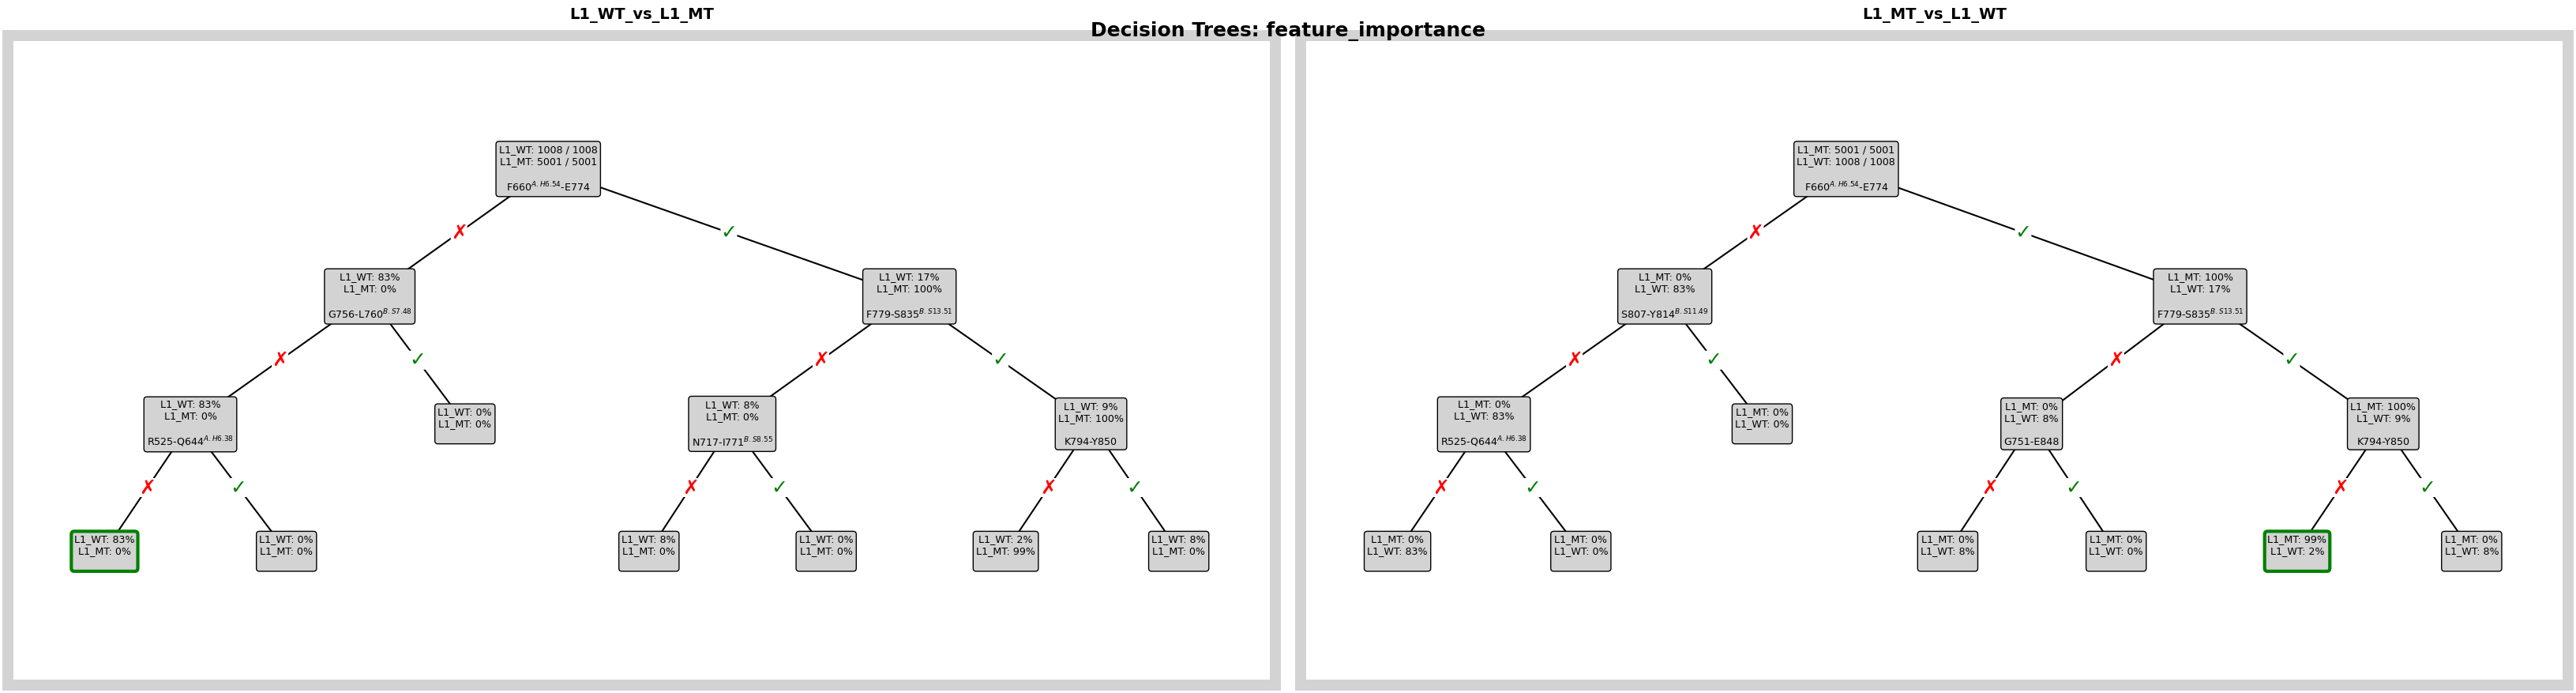

In [19]:
fig = pipeline.plots.feature_importance.decision_trees(
    feature_importance_name="feature_importance",
    short_layout=True,
    width_scale_factor=0.6,
    height_scale_factor=0.5,
    edge_symbol_fontsize=18,
)

## Inspect the Top Contacts with Violin Plots

Violin plots summarize how the most important contacts are distributed in both conditions. This is helpful for checking whether a contact cleanly separates WT and mutant or whether the difference is more subtle and overlapping.


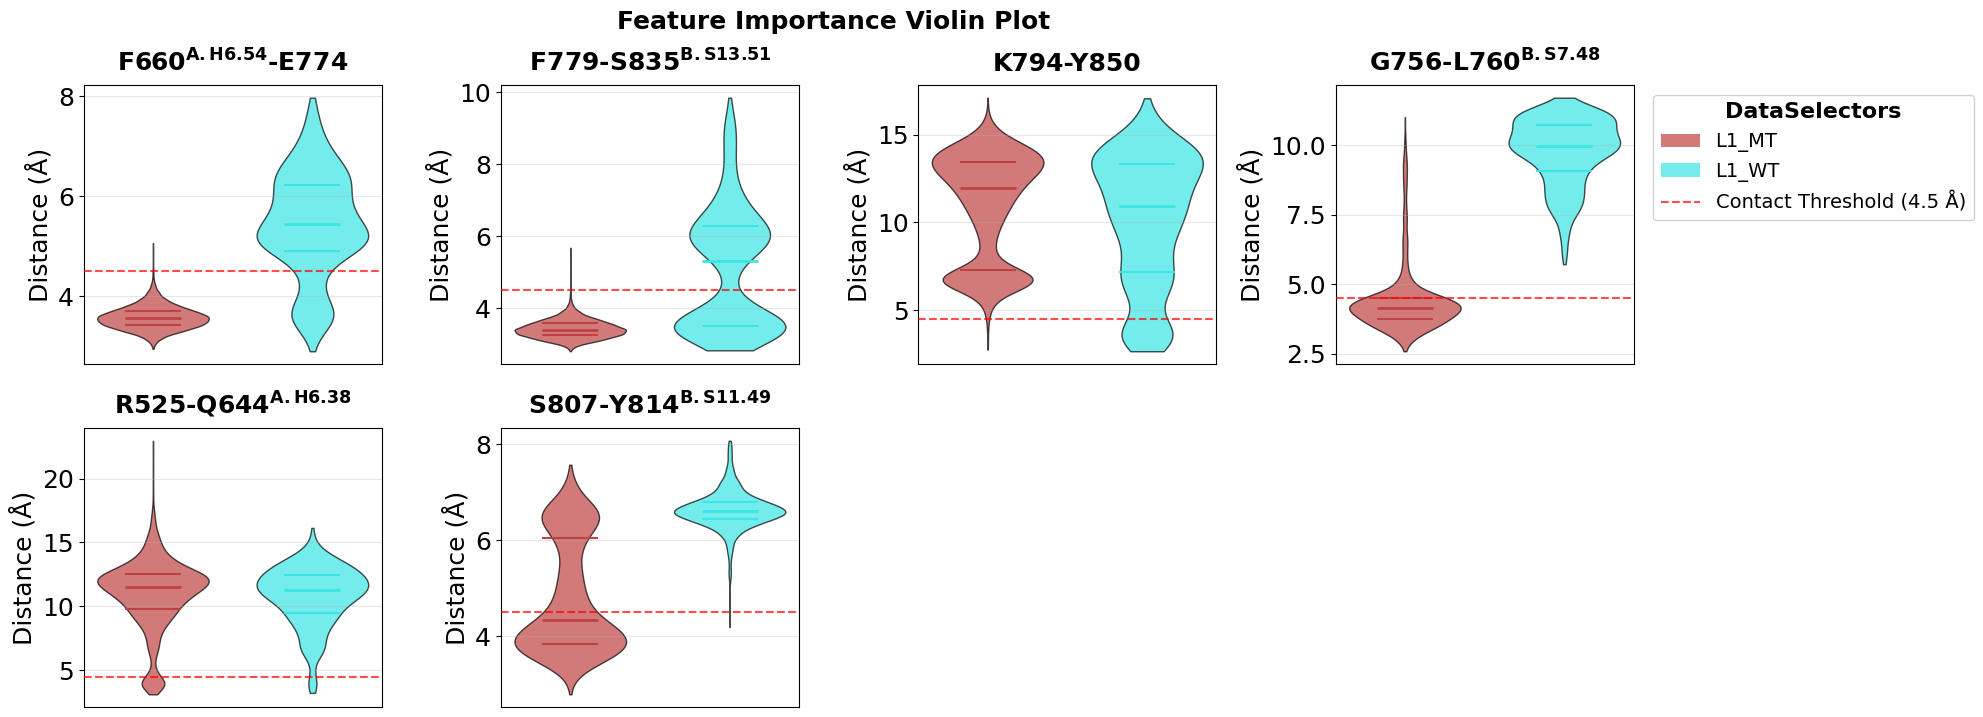

In [20]:
fig = pipeline.plots.feature_importance.violins(
    feature_importance_name="feature_importance",
    n_top=5,
    tick_fontsize=18,
    ylabel_fontsize=18,
    subplot_title_fontsize=18,
)

## Compare Contact Distributions as Densities

Density plots provide a complementary view of the same top contacts. They are especially useful when we want to compare the full shape of the distributions instead of only medians and quartiles.


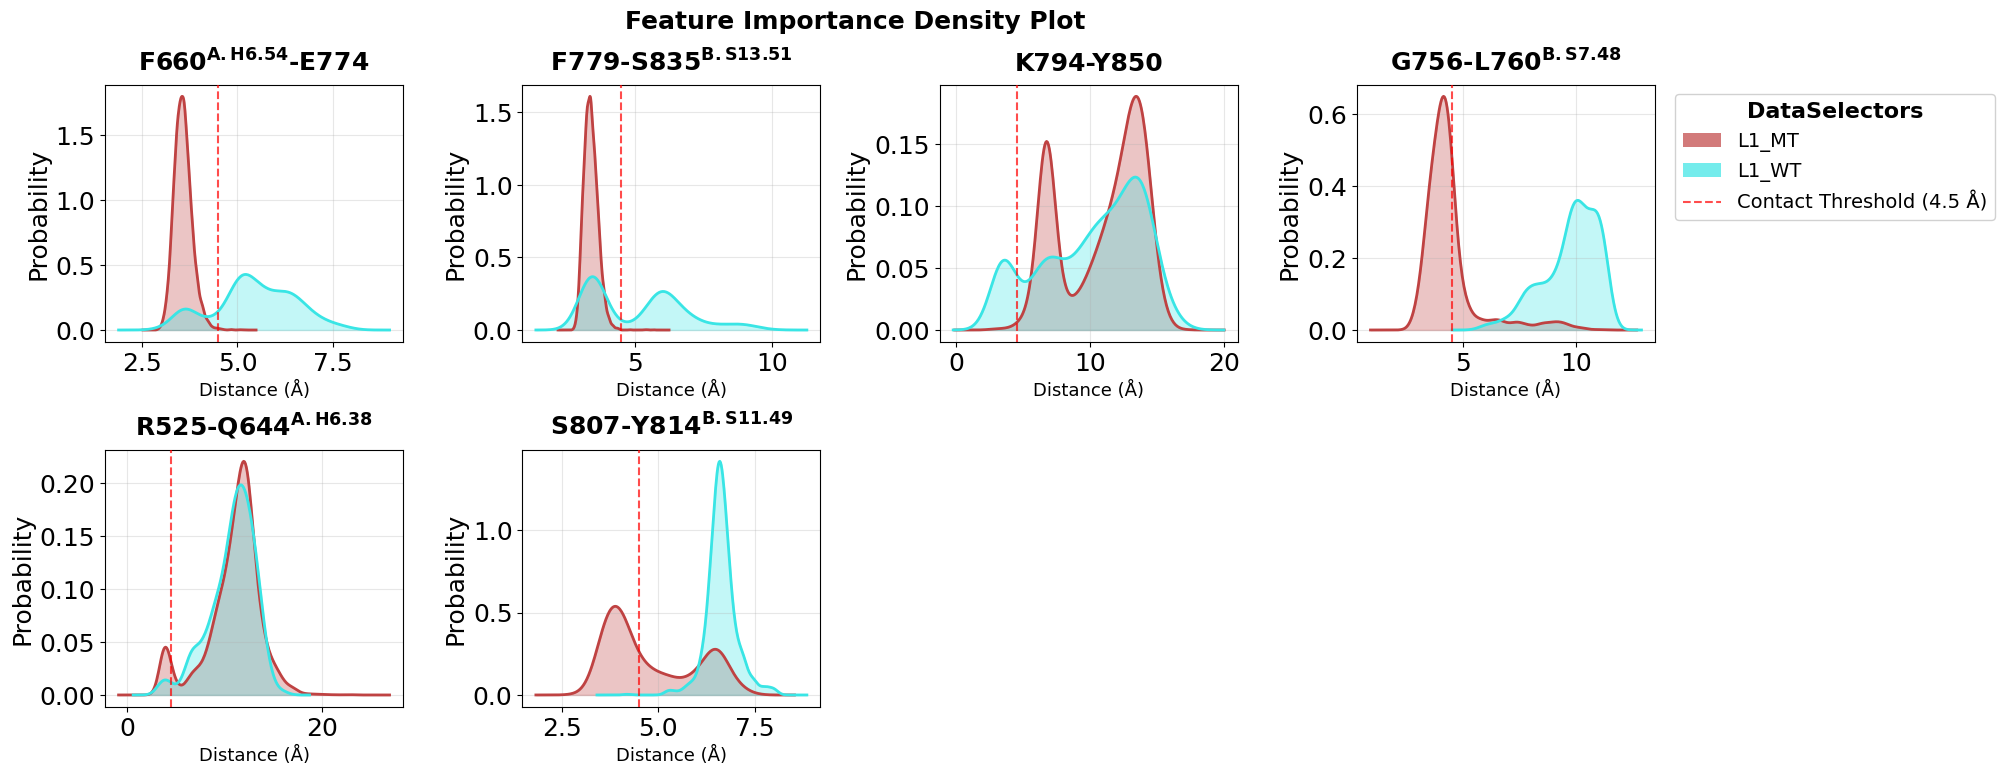

In [21]:
fig = pipeline.plots.feature_importance.densities(
    feature_importance_name="feature_importance",
    n_top=5,
    tick_fontsize=18,
    ylabel_fontsize=18,
    subplot_title_fontsize=18,
)

## Follow the Top Contacts over Time

Time-series plots show when the important contacts are present or absent during the trajectories. This adds temporal context and helps distinguish stable mutation effects from short-lived fluctuations.


Loading time data...
Loading time data...


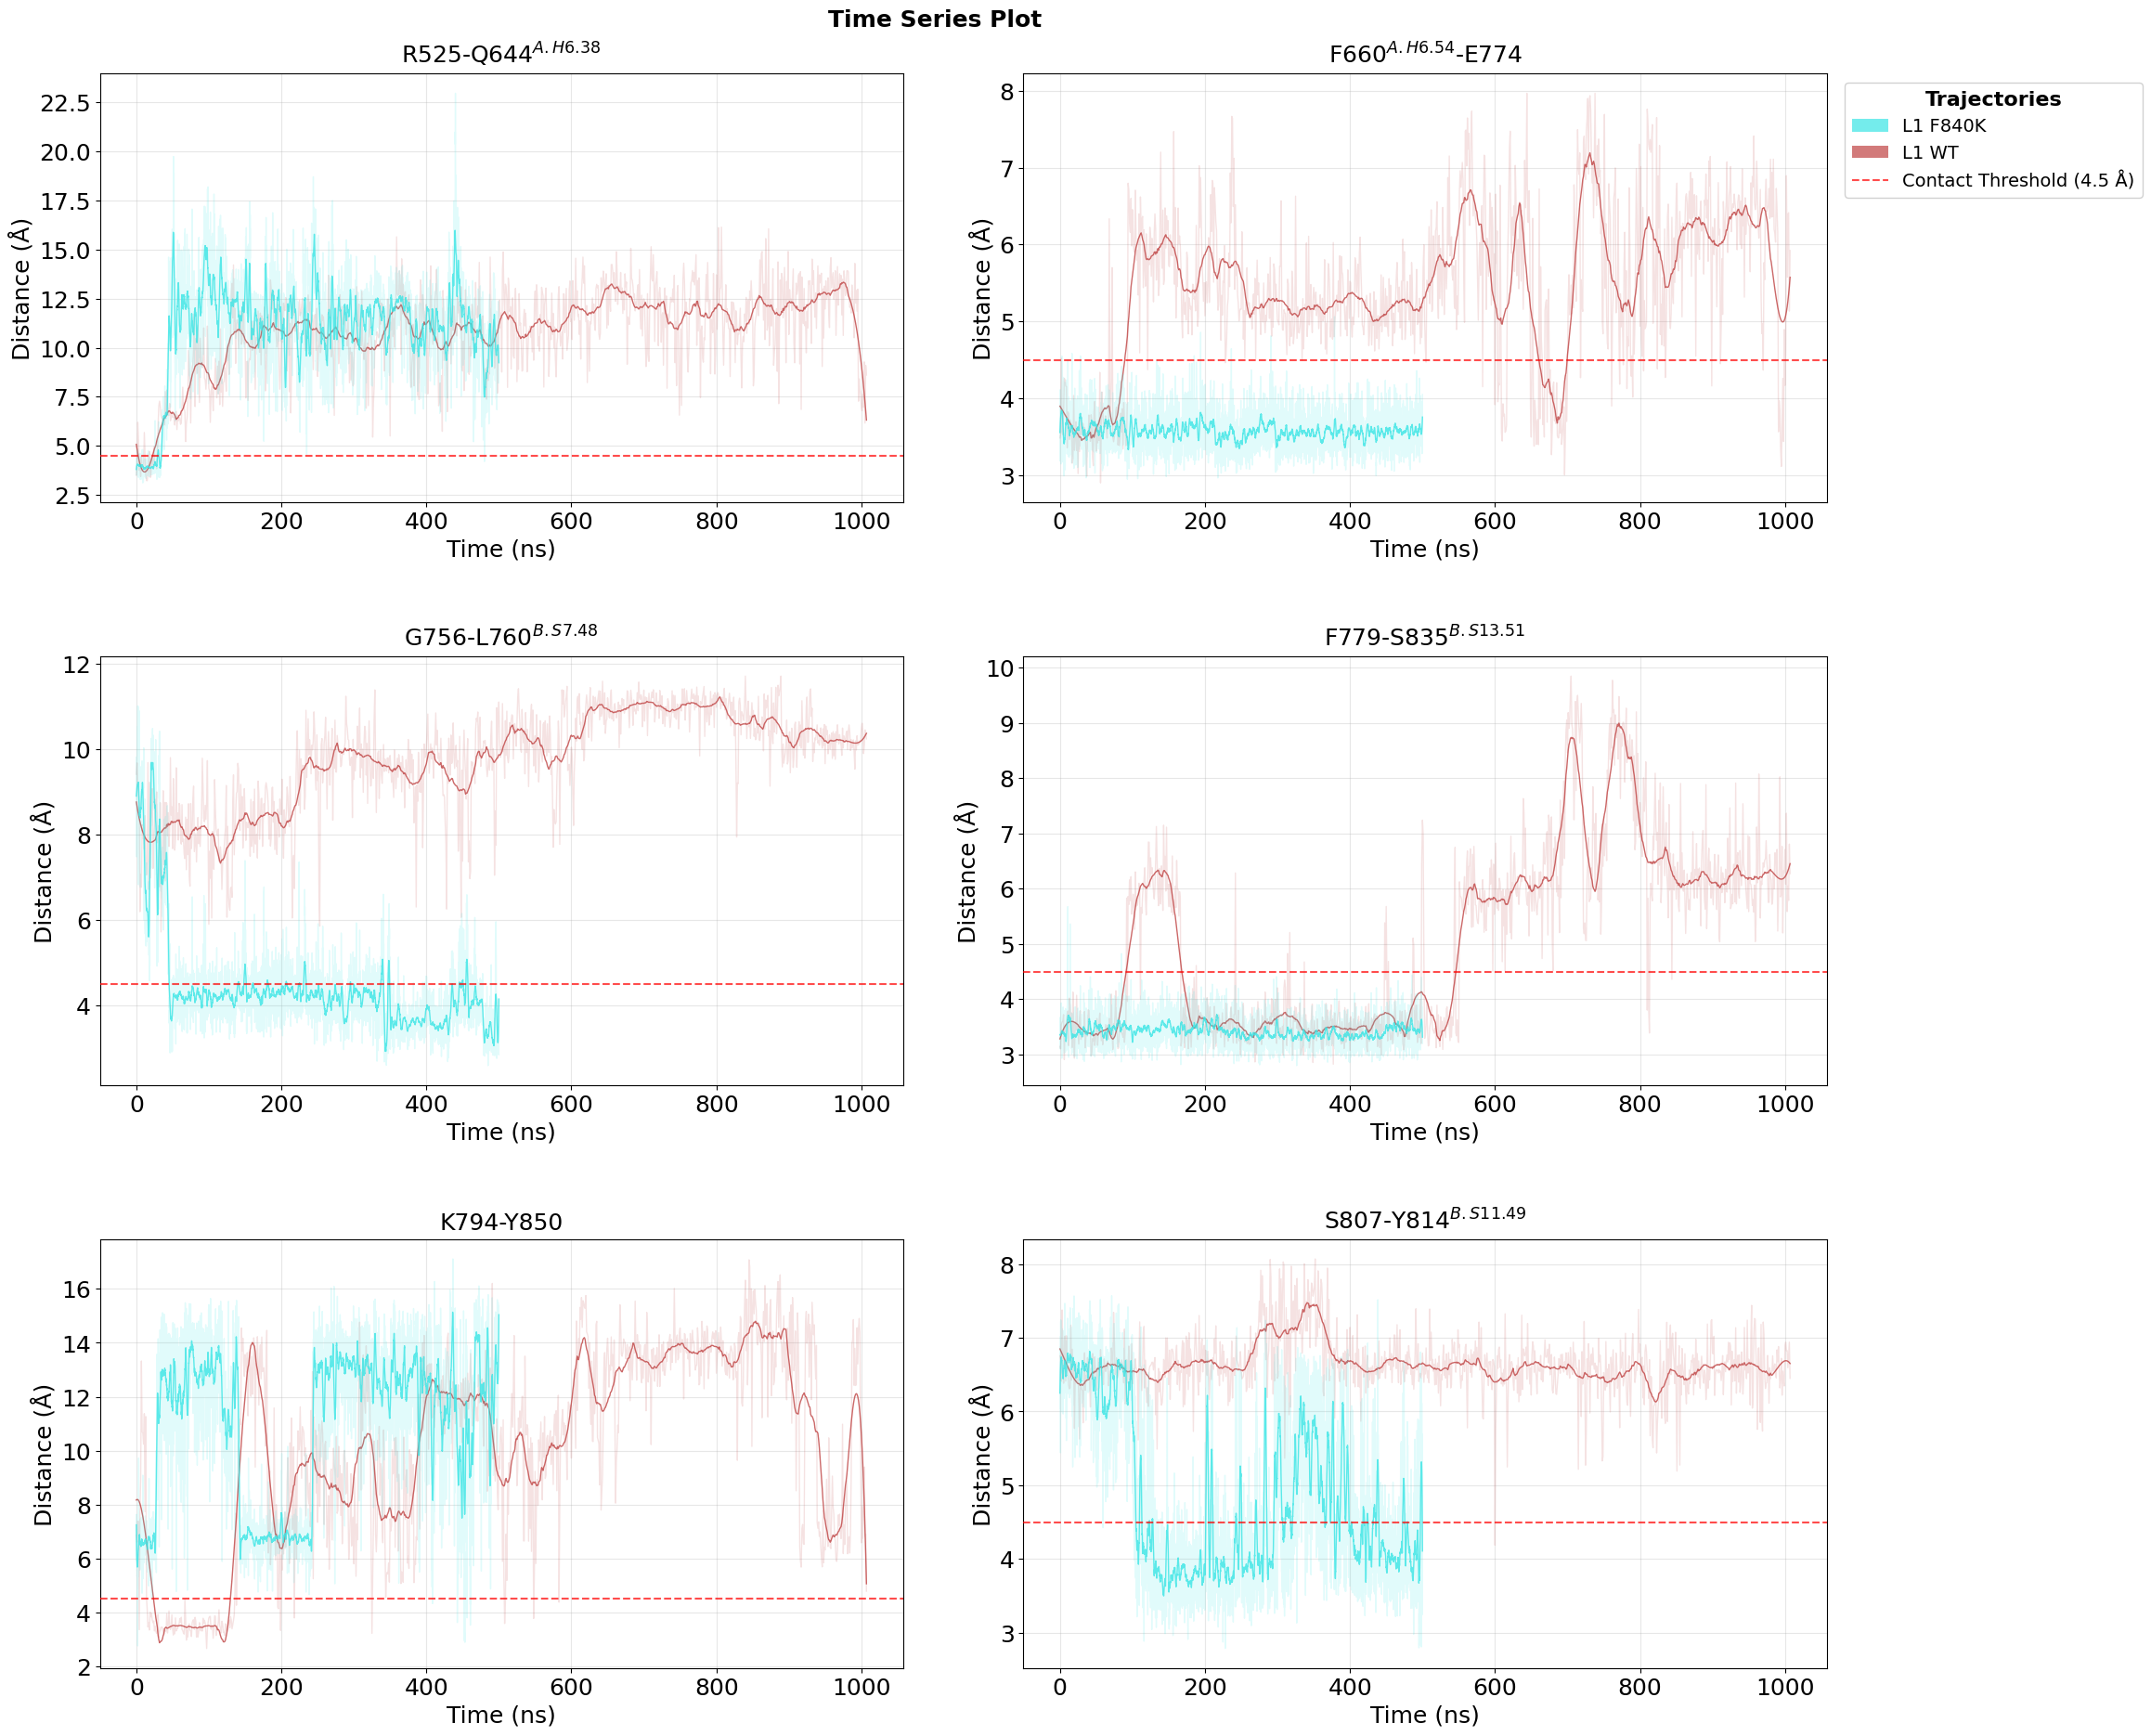

In [22]:
fig = pipeline.plots.feature_importance.time_series(
    feature_importance_name="feature_importance",
    n_top=5,
    tick_fontsize=18,
    ylabel_fontsize=18,
    xlabel_fontsize=18,
    subplot_title_fontsize=18,
)

## Map Importance Scores onto the Structure

We export PDB files in which feature-importance values are written into the B-factor column. This creates a simple bridge from the statistical comparison back to 3D structure interpretation.


In [23]:
pipeline.structure_visualization.feature_importance.create_pdb_with_beta_factors(
    structure_viz_name="structure_viz",
    feature_importance_name="feature_importance",
)

## Create a PyMOL Visualization Script

After generating the annotated PDB files, we create a PyMOL script for convenient structural inspection. This makes it easy to highlight the residues involved in the most discriminative contacts without manual setup.


In [24]:
pipeline.structure_visualization.feature_importance.create_pymol_script(
    structure_viz_name="structure_viz"
)

'C:\\Users\\maxim\\Documents\\projects\\mdxplain\\tutorials\\cache\\cache_b78c4519feac48e49dec64da61a13185_20260331_120500\\structure_viz\\structure_viz.pml'

## Save a Shareable Analysis Archive

Finally, we package the analysis results into a sharable archive. This is useful for reproducibility, handoff, and reusing the processed comparison without recomputing the whole workflow.


In [25]:
pipeline.create_sharable_archive(  
    "analysis_full.tar.zst",  
    exclude_visualizations=False  
)  

'C:\\Users\\maxim\\Documents\\projects\\mdxplain\\tutorials\\analysis_full.tar.zst'